<img src="../imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a|
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a|
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a|
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# Gráficos de correlação e regressão linear simples para a AV3

Notebook-fonte para gerar figuras didáticas usadas no guia de estudos da AV3.

Os dados são artificiais e controlados, com semente fixa, para destacar padrões visuais de associação, ajuste linear, resíduos, outliers e extrapolação.


In [1]:
import os
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str(Path("../.matplotlib").resolve())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from IPython.display import display

OUT_DIR = Path("../imgs").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#2563eb"
GREEN = "#16a34a"
ORANGE = "#f97316"
RED = "#dc2626"
GRAY = "#6b7280"

rng = np.random.default_rng(2026)

def save_fig(fig, filename):
    path = OUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return path

def fit_line(x, y):
    X_design = sm.add_constant(x)
    return sm.OLS(y, X_design).fit()

generated = []


## Correlação


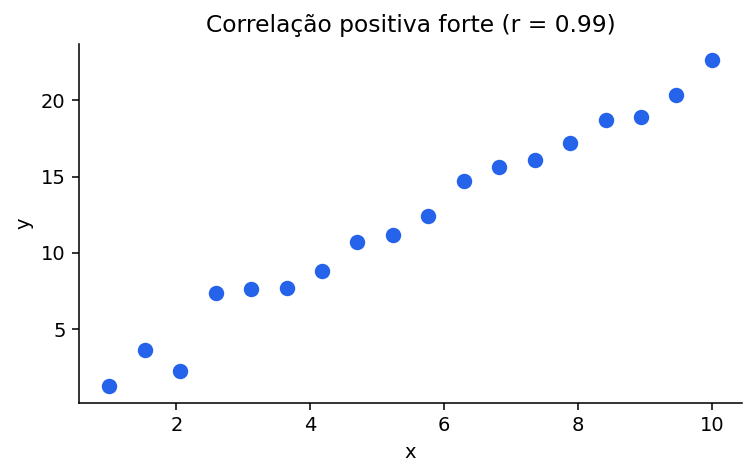

In [2]:
x = np.linspace(1, 10, 18)
y = 2.2 * x + rng.normal(0, 1.2, size=x.size)
r = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(x, y, color=BLUE, s=48)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Correlação positiva forte (r = {r:.2f})")
generated.append(save_fig(fig, "rls_correlacao_positiva.png"))


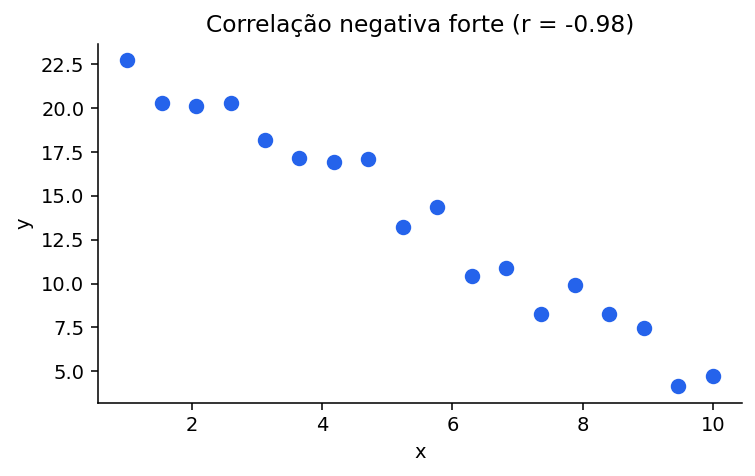

In [3]:
x = np.linspace(1, 10, 18)
y = 25 - 2.1 * x + rng.normal(0, 1.1, size=x.size)
r = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(x, y, color=BLUE, s=48)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Correlação negativa forte (r = {r:.2f})")
generated.append(save_fig(fig, "rls_correlacao_negativa.png"))


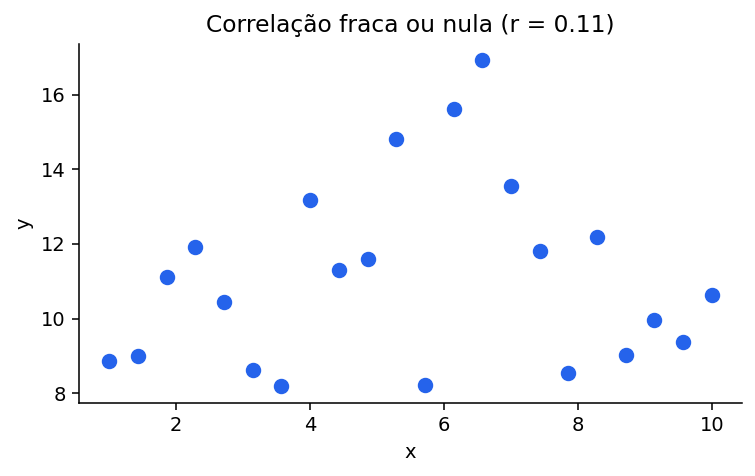

In [4]:
x = np.linspace(1, 10, 22)
y = rng.normal(10, 2.2, size=x.size)
r = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(x, y, color=BLUE, s=48)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Correlação fraca ou nula (r = {r:.2f})")
generated.append(save_fig(fig, "rls_correlacao_fraca.png"))


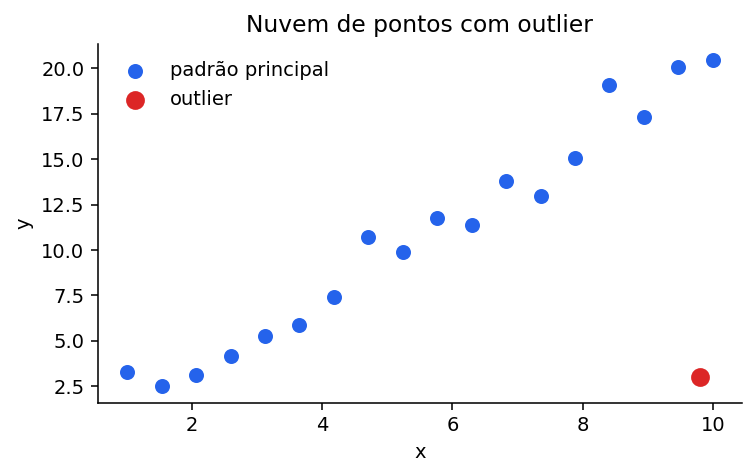

In [5]:
x_base = np.linspace(1, 10, 18)
y_base = 2.0 * x_base + rng.normal(0, 1.0, size=x_base.size)
x = np.append(x_base, 9.8)
y = np.append(y_base, 3.0)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(x_base, y_base, color=BLUE, s=45, label="padrão principal")
ax.scatter([x[-1]], [y[-1]], color=RED, s=75, label="outlier")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Nuvem de pontos com outlier")
ax.legend(frameon=False)
generated.append(save_fig(fig, "rls_outlier.png"))


## Regressão linear simples


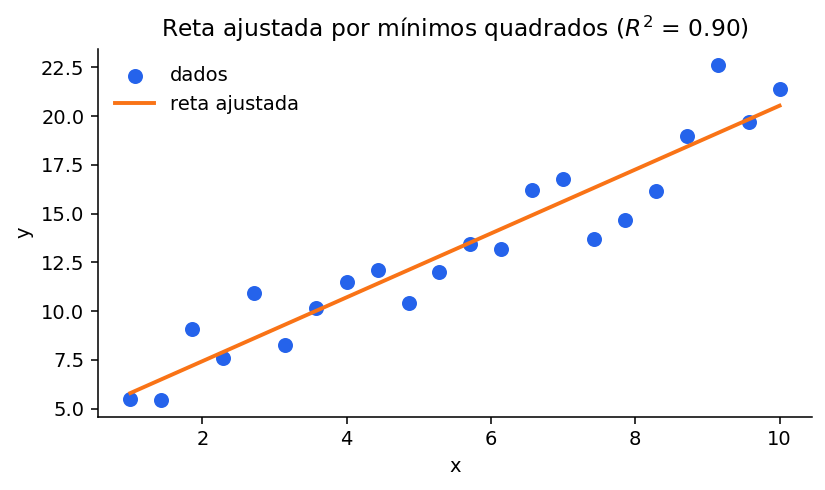

In [6]:
x = np.linspace(1, 10, 22)
y = 4 + 1.7 * x + rng.normal(0, 1.5, size=x.size)
model = fit_line(x, y)
x_grid = np.linspace(x.min(), x.max(), 100)
y_hat_grid = model.params[0] + model.params[1] * x_grid

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.scatter(x, y, color=BLUE, s=45, label="dados")
ax.plot(x_grid, y_hat_grid, color=ORANGE, linewidth=2, label="reta ajustada")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Reta ajustada por mínimos quadrados ($R^2$ = {model.rsquared:.2f})")
ax.legend(frameon=False)
generated.append(save_fig(fig, "rls_reta_ajustada.png"))


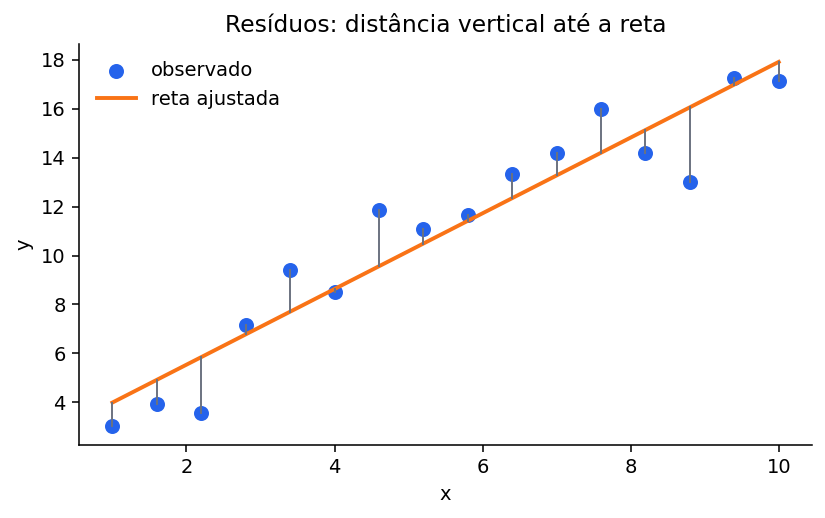

In [7]:
x = np.linspace(1, 10, 16)
y = 3 + 1.5 * x + rng.normal(0, 1.4, size=x.size)
model = fit_line(x, y)
fitted = model.fittedvalues
order = np.argsort(x)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.scatter(x, y, color=BLUE, s=45, label="observado")
ax.plot(x[order], fitted[order], color=ORANGE, linewidth=2, label="reta ajustada")
for xi, yi, yhi in zip(x, y, fitted):
    ax.plot([xi, xi], [yhi, yi], color=GRAY, linewidth=1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Resíduos: distância vertical até a reta")
ax.legend(frameon=False)
generated.append(save_fig(fig, "rls_residuos.png"))


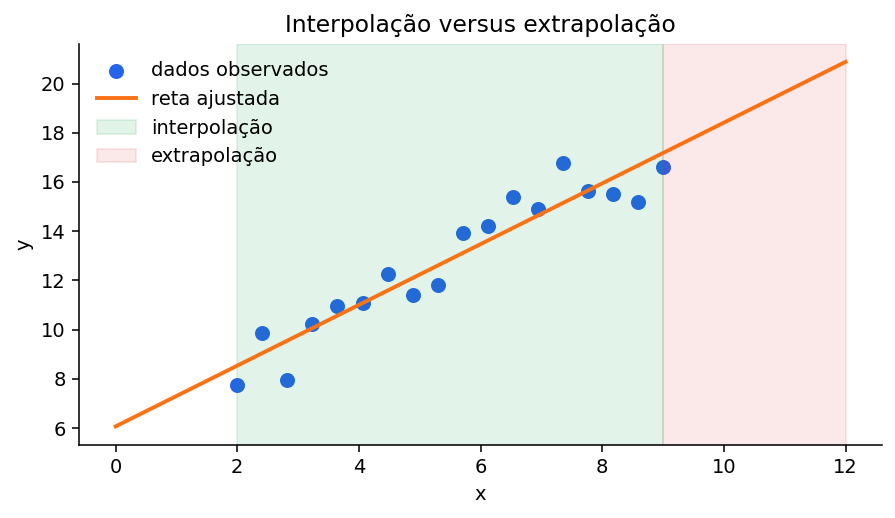

In [8]:
x = np.linspace(2, 9, 18)
y = 5 + 1.4 * x + rng.normal(0, 0.9, size=x.size)
model = fit_line(x, y)
x_grid = np.linspace(0, 12, 160)
y_grid = model.params[0] + model.params[1] * x_grid

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.scatter(x, y, color=BLUE, s=45, label="dados observados")
ax.plot(x_grid, y_grid, color=ORANGE, linewidth=2, label="reta ajustada")
ax.axvspan(x.min(), x.max(), color=GREEN, alpha=0.12, label="interpolação")
ax.axvspan(x.max(), 12, color=RED, alpha=0.10, label="extrapolação")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Interpolação versus extrapolação")
ax.legend(frameon=False, loc="upper left")
generated.append(save_fig(fig, "rls_interpolacao_extrapolacao.png"))


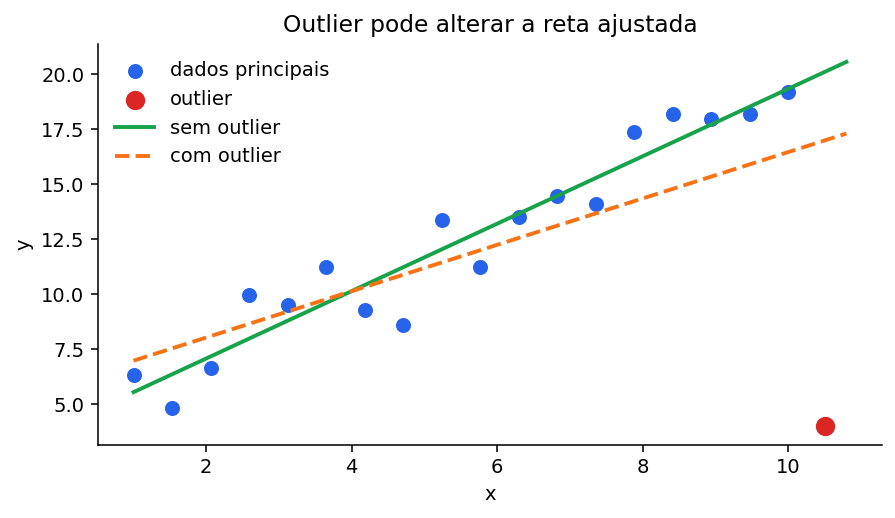

In [9]:
x_base = np.linspace(1, 10, 18)
y_base = 4 + 1.5 * x_base + rng.normal(0, 1.0, size=x_base.size)
x_out = np.append(x_base, 10.5)
y_out = np.append(y_base, 4.0)

model_base = fit_line(x_base, y_base)
model_out = fit_line(x_out, y_out)
x_grid = np.linspace(1, 10.8, 120)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.scatter(x_base, y_base, color=BLUE, s=45, label="dados principais")
ax.scatter([x_out[-1]], [y_out[-1]], color=RED, s=80, label="outlier")
ax.plot(x_grid, model_base.params[0] + model_base.params[1] * x_grid, color=GREEN, linewidth=2, label="sem outlier")
ax.plot(x_grid, model_out.params[0] + model_out.params[1] * x_grid, color=ORANGE, linewidth=2, linestyle="--", label="com outlier")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Outlier pode alterar a reta ajustada")
ax.legend(frameon=False)
generated.append(save_fig(fig, "rls_outlier_influencia.png"))


In [10]:
pd.DataFrame({"arquivo": [p.name for p in generated]})


,arquivo
0,rls_correlacao_positiva.png
1,rls_correlacao_negativa.png
2,rls_correlacao_fraca.png
3,rls_outlier.png
4,rls_reta_ajustada.png
5,rls_residuos.png
6,rls_interpolacao_extrapolacao.png
7,rls_outlier_influencia.png
